# Importing Data

In [20]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_predict, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc
import time
import warnings
warnings.filterwarnings('ignore')

In [21]:
all_sheets = pd.read_excel('DiabetesCleaned.xlsx', sheet_name=None)

# Extract each sheet into individual Dataframes
train_data = all_sheets['Train Data']
train_transformed = all_sheets['Train Transformed Data']
val_data = all_sheets['Validate Data']
val_transformed = all_sheets['Validate Transformed Data']
test_data = all_sheets['Test Data']
test_transformed = all_sheets['Test Transformed Data']

In [22]:
# Split features into X and Y for easier processing
target_column = 'Outcome'

# Split Train Data
X_train = train_data.drop(columns=[target_column])
y_train = train_data[target_column]

# Split Train Transformed Data
X_train_transformed = train_transformed.drop(columns=[target_column])
y_train_transformed = train_transformed[target_column]

# Split Validation Data
X_val = val_data.drop(columns=[target_column])
y_val = val_data[target_column]

# Split Validation Transformed Data
X_val_transformed = val_transformed.drop(columns=[target_column])
y_val_transformed = val_transformed[target_column]

# Split Test Data
X_test = test_data.drop(columns=[target_column])
y_test = test_data[target_column]

# Split Test Transformed Data
X_test_transformed = test_transformed.drop(columns=[target_column])
y_test_transformed = test_transformed[target_column]

# Standardizing Data

In [23]:
scaler = StandardScaler()

# Standardizing data for Modeling
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Standardizing data for Modeling with transformed data
X_train_transformed_scaled = scaler.fit_transform(X_train_transformed)
X_val_transformed_scaled = scaler.transform(X_val_transformed)
X_test_transformed_scaled = scaler.transform(X_test_transformed)

# Modeling

## ROC AUC graph function


In [24]:
def get_roc_auc(y_true, y_scores):
    # Plot ROC AUC curve
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = roc_auc_score(y_true, y_scores)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

## Define Models to be train

In [25]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
optuna.logging.disable_default_handler()

# Must transform - will perform poorly without it
transform_required = {
    'LinearSVC': LinearSVC(random_state=42),
    'SVC': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'MLP': MLPClassifier(random_state=42, max_iter=1000),
    'LogisticRegression': LogisticRegression(random_state=42),
    'GaussianNB': GaussianNB()
    # 'DeepMLP': KerasClassifier(model=make_mlp, epochs=50, batch_size=32, verbose=0)
    # 'TabNet': TabNetClassifier(seed=42),
}

# Can handle raw data well
robust_models = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

# Test both approaches
hybrid_models = {
    'XGBoost': xgb.XGBClassifier(random_state=42)
}

## Transform_Reqired Dataset

### LinearSVC

In [26]:
# Hyper parameter tuning for LinearSVC
def obj_linear_svc(trial):
    # Hyperparameter tuning suggestions for LinearSVC fields
    C = trial.suggest_float('C', 0.01, 100.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    loss = trial.suggest_categorical('loss', ['hinge', 'squared_hinge'])
    tol = trial.suggest_float('tol', 1e-5, 1e-2, log=True)
    max_iter = trial.suggest_int('max_iter', 1000, 10000, step=500)
    class_weight = trial.suggest_categorical('class_weight', [
        None, 'balanced', {0: 1.0, 1: 1.3}, {0: 1.0, 1: 1.5}
    ])

    # CONSTRAINTS BASED ON https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html
    # If penalty is 'l1', force loss to be 'squared_hinge'
    if penalty == 'l1' and loss == 'hinge':
        loss = 'squared_hinge'
    
    # - penalty='l1': dual must be False
    # - penalty='l2' and loss='hinge': dual must be True
    # - penalty='l2' and loss='squared_hinge': dual can be True or False
    if penalty == 'l1':
        dual = False
    elif penalty == 'l2' and loss == 'hinge':
        dual = True
    else:
        dual = trial.suggest_categorical('dual', [True, False])
    
    # Define the model
    model = LinearSVC(
        C=C,
        penalty=penalty,
        loss=loss,
        dual=dual,
        tol=tol,
        max_iter=max_iter,
        class_weight=class_weight,
        random_state=42
    )

    # Get f1_score
    f1_score = cross_val_score(
        model, 
        X_train_transformed_scaled,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro'
    ).mean()

    return f1_score

# Use Optuna to optimize the LinearSVC model
study_linear_svc = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_linear_svc.optimize(obj_linear_svc, n_trials=100)

print(f"Best hyperparameters for LinearSVC: {study_linear_svc.best_params}")
print(f"Best f1_score for LinearSVC: {study_linear_svc.best_value}")

def solve_invalid_hyperparameters(params):
    params = params.copy()
    if params.get('penalty') == 'l1' and params.get('loss') == 'hinge':
        params['loss'] = 'squared_hinge'
    if params.get('penalty') == 'l1':
        params['dual'] = False
    elif params.get('penalty') == 'l2' and params.get('loss') == 'hinge':
        params['dual'] = True
    return params

# Train LinearSVC using best params 
best_linear_svc = LinearSVC(
    **solve_invalid_hyperparameters(study_linear_svc.best_params),
    random_state=42
)
best_linear_svc.fit(X_train_transformed_scaled, y_train)

# Evaluate LinearSVC on val and test data
y_val_pred_linear_svc = best_linear_svc.predict(X_val_transformed_scaled)
y_test_pred_linear_svc = best_linear_svc.predict(X_test_transformed_scaled)

Best hyperparameters for LinearSVC: {'C': 0.40469878029473777, 'penalty': 'l1', 'loss': 'hinge', 'tol': 5.9567517243918656e-05, 'max_iter': 10000, 'class_weight': {0: 1.0, 1: 1.3}}
Best f1_score for LinearSVC: 0.7452833063710016


LinearSVC Validation Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.34      0.98      0.51        53

    accuracy                           0.34       153
   macro avg       0.17      0.49      0.25       153
weighted avg       0.12      0.34      0.18       153



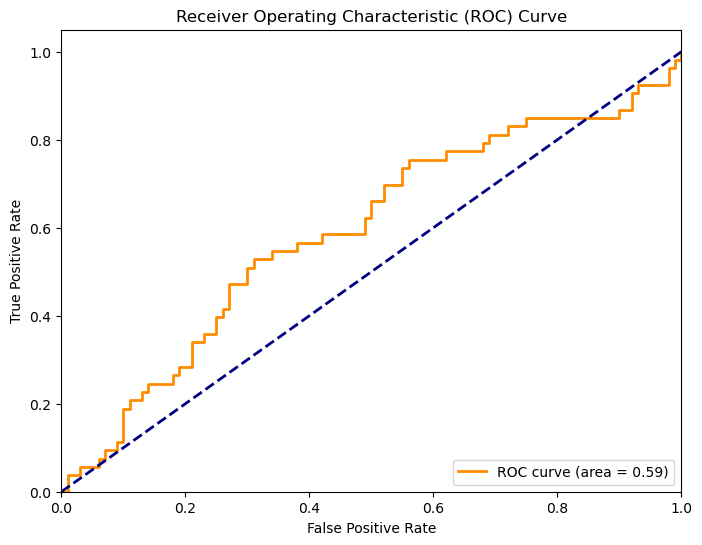

LinearSVC Test Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.35      0.98      0.51        54

    accuracy                           0.34       154
   macro avg       0.17      0.49      0.26       154
weighted avg       0.12      0.34      0.18       154



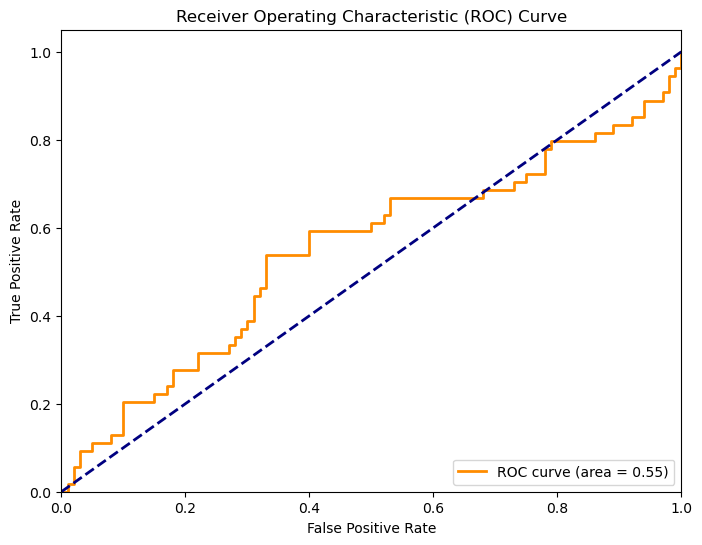

In [27]:
# Output
print("LinearSVC Validation Classification Report:")
print(classification_report(y_val, y_val_pred_linear_svc))
get_roc_auc(y_val, best_linear_svc.decision_function(X_val_transformed_scaled))

print("LinearSVC Test Classification Report:")
print(classification_report(y_test, y_test_pred_linear_svc))
get_roc_auc(y_test, best_linear_svc.decision_function(X_test_transformed_scaled))

### SVC

In [28]:
# Hyper parameter tuning for SVC
def obj_svc(trial):
    # Hyperparameter tuning suggestions for SVC fields
    C = trial.suggest_float('C', 0.01, 100.0, log=True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])
    degree = trial.suggest_int('degree', 2, 5) if kernel == 'poly' else 1
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'] + [0.001, 0.01, 0.1, 1, 10]) if kernel in ['poly', 'rbf', 'sigmoid'] else 1
    coef0 = trial.suggest_float('coef0', 0.0, 1.0, step=0.05) if kernel in ['poly', 'rbf'] else 0.0
    tol = trial.suggest_float('tol', 1e-5, 1e-2, log=True)
    max_iter = trial.suggest_int('max_iter', 1000, 10000, step=500)
    
    # Define the model
    model = SVC(
        C = C,
        kernel = kernel,
        degree = degree,
        gamma = gamma,
        coef0 = coef0,
        tol = tol,
        max_iter = max_iter,
        random_state=42
    )

    # Get f1_score
    f1_score = cross_val_score(
        model, 
        X_train_transformed_scaled,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro'
    ).mean()

    return f1_score

# Use Optuna to optimize the SVC model
study_svc = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_svc.optimize(obj_svc, n_trials=100)

print(f"Best hyperparameters for SVC: {study_svc.best_params}")
print(f"Best f1_score for SVC: {study_svc.best_value}")

# Train SVC using best params 
best_svc = SVC(
    **study_svc.best_params,
    random_state=42
)
best_svc.fit(X_train_transformed_scaled, y_train)

# Evaluate SVC on val and test data
y_val_pred_svc = best_svc.predict(X_val_transformed_scaled)
y_test_pred_svc = best_svc.predict(X_test_transformed_scaled)

Best hyperparameters for SVC: {'C': 25.19431244764185, 'kernel': 'poly', 'degree': 4, 'gamma': 0.01, 'coef0': 0.9, 'tol': 0.009633503888937101, 'max_iter': 3000}
Best f1_score for SVC: 0.7478569982414792


SVC Validation Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.35      1.00      0.51        53

    accuracy                           0.35       153
   macro avg       0.17      0.50      0.26       153
weighted avg       0.12      0.35      0.18       153



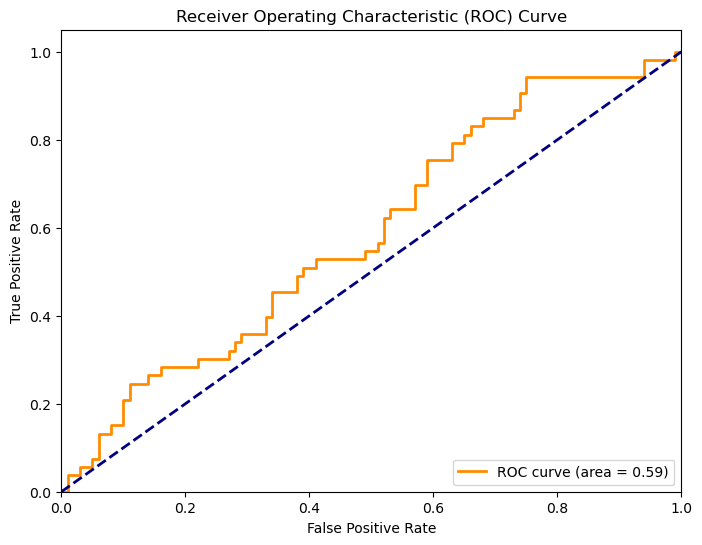

SVC Test Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.35      1.00      0.52        54

    accuracy                           0.35       154
   macro avg       0.18      0.50      0.26       154
weighted avg       0.12      0.35      0.18       154



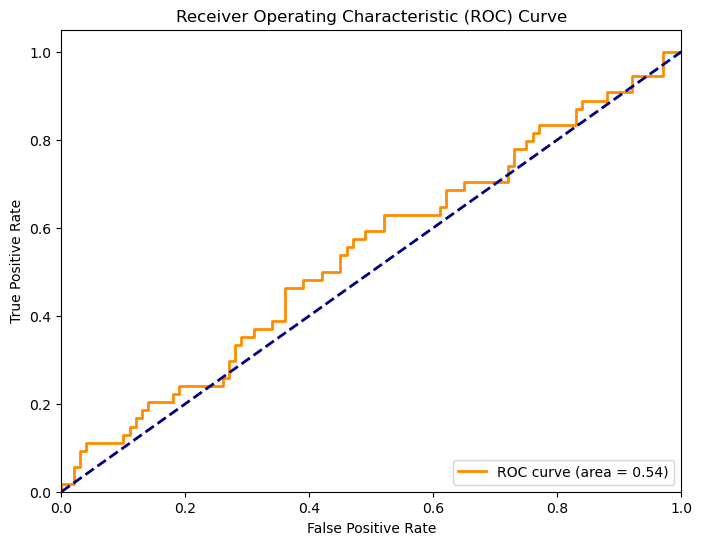

In [29]:
# Output
print("SVC Validation Classification Report:")
print(classification_report(y_val, y_val_pred_svc))
get_roc_auc(y_val, best_svc.decision_function(X_val_transformed_scaled))

print("SVC Test Classification Report:")
print(classification_report(y_test, y_test_pred_svc))
get_roc_auc(y_test, best_svc.decision_function(X_test_transformed_scaled))

### K-NN

In [30]:
# Hyper parameter tuning for K-NN
def obj_knn(trial):
    # Hyperparameter tuning suggestions for K-NN fields
    n_neighbors = trial.suggest_int("n_neighbors", 4, 56, step=1)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    metric = trial.suggest_categorical("metric", ["euclidean", "manhattan", "minkowski"])
    p = trial.suggest_int("p", 1, 2) if metric == "minkowski" else 2

    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
        metric=metric,
        p=p
    )

    # Get f1_score
    f1_score = cross_val_score(
        model, 
        X_train_transformed_scaled,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro'
    ).mean()

    return f1_score

# Use Optuna to optimize the KNN model
study_KNN = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_KNN.optimize(obj_knn, n_trials=100)

print(f"Best hyperparameters for K-NN: {study_KNN.best_params}")
print(f"Best f1_score for K-NN: {study_KNN.best_value}")

# Train KNN using best params 
best_knn = KNeighborsClassifier(
    **study_KNN.best_params,
)
best_knn.fit(X_train_transformed_scaled, y_train)

# Evaluate knn on val and test data
y_val_pred_knn = best_knn.predict(X_val_transformed_scaled)
y_test_pred_knn = best_knn.predict(X_test_transformed_scaled)

Best hyperparameters for K-NN: {'n_neighbors': 49, 'weights': 'uniform', 'metric': 'manhattan'}
Best f1_score for K-NN: 0.7192041196592


K-NN Validation Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       100
           1       0.66      0.55      0.60        53

    accuracy                           0.75       153
   macro avg       0.72      0.70      0.71       153
weighted avg       0.74      0.75      0.74       153



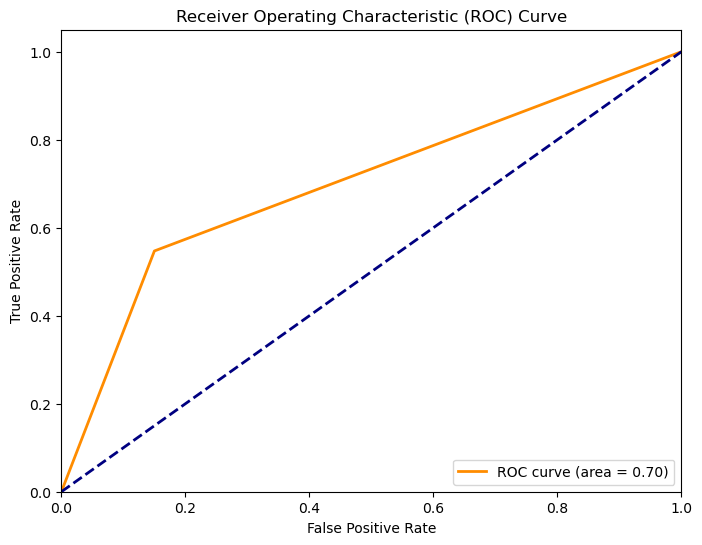

K-NN Test Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.84      0.78       100
           1       0.58      0.41      0.48        54

    accuracy                           0.69       154
   macro avg       0.65      0.62      0.63       154
weighted avg       0.67      0.69      0.67       154



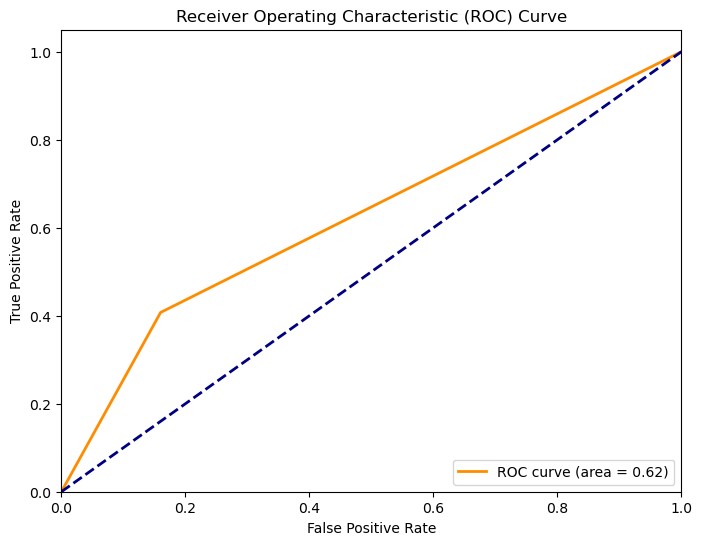

In [31]:
# Output
print("K-NN Validation Classification Report:")
print(classification_report(y_val, y_val_pred_knn))
get_roc_auc(y_val, y_val_pred_knn)

print("K-NN Test Classification Report:")
print(classification_report(y_test, y_test_pred_knn))
get_roc_auc(y_test, y_test_pred_knn)

### MLP

In [32]:
# Hyper parameter tuning for MLP
def obj_MLP(trial):
    # Hyperparameter tuning suggestions for MLP fields
    hidden_layer_sizes = trial.suggest_categorical(
        "hidden_layer_sizes",
        [(64,), (128,), (256,),
         (64,64), (128,64), (128,128),
         (256,128), (256,256)]
    )
    activation = trial.suggest_categorical("activation", ["relu", "tanh", "logistic"])
    solver = trial.suggest_categorical("solver", ["adam", "sgd"])
    alpha = trial.suggest_float("alpha", 1e-6, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])
    learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-1, log=True)

    # learning_rate depends on solver
    if solver == "sgd":
        learning_rate = trial.suggest_categorical("learning_rate", ["constant", "invscaling", "adaptive"])
        momentum = trial.suggest_float("momentum", 0.49, 0.99)
        nesterovs_momentum = trial.suggest_categorical("nesterovs_momentum", [True, False])
    else:
        learning_rate = "constant"
        momentum = 0.9
        nesterovs_momentum = False
        beta_1 = trial.suggest_float("beta_1", 0.8, 0.99)
        beta_2 = trial.suggest_float("beta_2", 0.9, 0.999)

    max_iter = trial.suggest_int("max_iter", 500, 2000)
    tol = trial.suggest_float("tol", 1e-5, 1e-3, log=True)

    # model based on solver
    if solver == "adam":
        model = MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            activation=activation,
            solver=solver,
            alpha=alpha,
            batch_size=batch_size,
            learning_rate=learning_rate,
            learning_rate_init=learning_rate_init,
            beta_1=beta_1,
            beta_2=beta_2,
            max_iter=max_iter,
            tol=tol,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            random_state=42
        )
    else:
        model = MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            activation=activation,
            solver=solver,
            alpha=alpha,
            batch_size=batch_size,
            learning_rate=learning_rate,
            learning_rate_init=learning_rate_init,
            momentum=momentum,
            nesterovs_momentum=nesterovs_momentum,
            max_iter=max_iter,
            tol=tol,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            random_state=42
        )

    # Get f1_score
    f1_score = cross_val_score(
        model, 
        X_train_transformed_scaled,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro'
    ).mean()

    return f1_score

# Use Optuna to optimize the MLP model
study_MLP = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_MLP.optimize(obj_MLP, n_trials=100)

print(f"Best hyperparameters for MLP: {study_MLP.best_params}")
print(f"Best f1_score for MLP: {study_MLP.best_value}")

# Train MLP using best params 
best_MLP = MLPClassifier(
    **study_MLP.best_params,
    random_state=42
)
best_MLP.fit(X_train_transformed_scaled, y_train)

# Evaluate MLP on val and test data
y_val_pred_MLP = best_MLP.predict(X_val_transformed_scaled)
y_test_pred_MLP = best_MLP.predict(X_test_transformed_scaled)

Best hyperparameters for MLP: {'hidden_layer_sizes': (128, 128), 'activation': 'tanh', 'solver': 'adam', 'alpha': 3.5702502198387074e-05, 'batch_size': 128, 'learning_rate_init': 0.0020211696160687947, 'beta_1': 0.90803972977332, 'beta_2': 0.9919252356695921, 'max_iter': 1423, 'tol': 2.6547253109290104e-05}
Best f1_score for MLP: 0.758786033985559


MLP Validation Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.34      0.98      0.51        53

    accuracy                           0.34       153
   macro avg       0.17      0.49      0.25       153
weighted avg       0.12      0.34      0.18       153



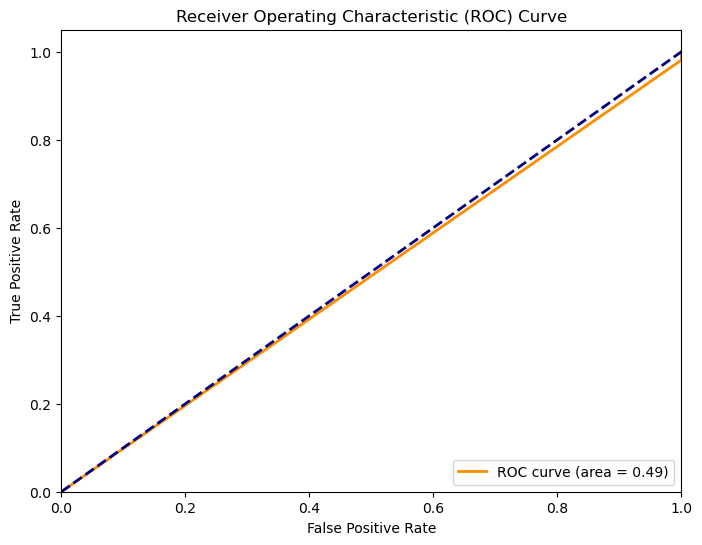

MLP Test Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.35      1.00      0.52        54

    accuracy                           0.35       154
   macro avg       0.18      0.50      0.26       154
weighted avg       0.12      0.35      0.18       154



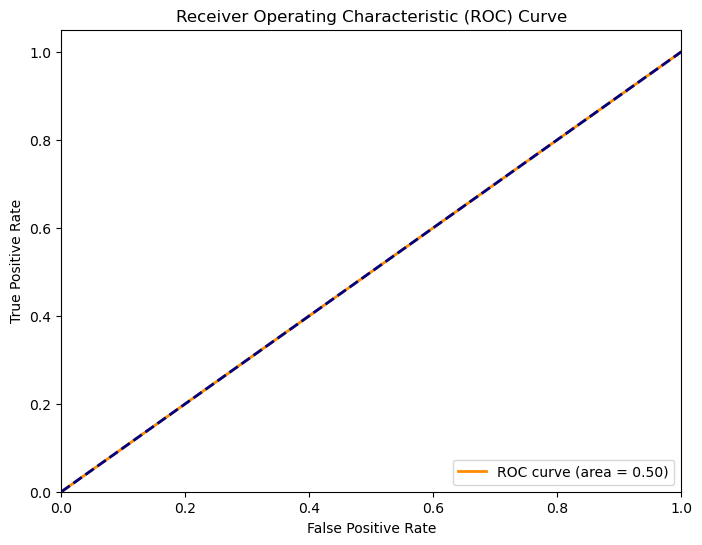

In [33]:
print("MLP Validation Classification Report:")
print(classification_report(y_val, y_val_pred_MLP))
get_roc_auc(y_val, y_val_pred_MLP)

print("MLP Test Classification Report:")
print(classification_report(y_test, y_test_pred_MLP))
get_roc_auc(y_test, y_test_pred_MLP)

### Logistic Regression

In [35]:
# Hyper parameter tuning for logistic_regression
def obj_logistic_regression(trial):
    # Hyperparameter tuning suggestions for logistic_regression fields
    penalty = trial.suggest_categorical("penalty", ["l2", "elasticnet"])
    solver = trial.suggest_categorical("solver", ["lbfgs", "saga"])
    if penalty == "elasticnet":
        solver = "saga"
        l1_ratio = trial.suggest_float("l1_ratio", 0.05, 0.95)
    else:
        l1_ratio = None

    C = trial.suggest_float("C", 1e-3, 1e3)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])
    max_iter = trial.suggest_int("max_iter", 200, 6000, step=200)
    tol = trial.suggest_float("tol", 1e-6, 1e-3, log=True)

    model = LogisticRegression(
        penalty=penalty, 
        solver=solver, 
        l1_ratio=l1_ratio,
        C=C, 
        class_weight=class_weight, 
        tol=tol,
        max_iter=max_iter,
        random_state=42, 
        n_jobs=None
    )

    # Get f1_score
    f1_score = cross_val_score(
        model, 
        X_train_transformed_scaled,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro'
    ).mean()

    return f1_score

# Use Optuna to optimize the logistic_regression model
study_logistic_regression = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_logistic_regression.optimize(obj_logistic_regression, n_trials=100)

print(f"Best hyperparameters for logistic_regression: {study_logistic_regression.best_params}")
print(f"Best f1_score for logistic_regression: {study_logistic_regression.best_value}")

def solve_invalid_hyperparameters(params):
    params = params.copy()
    if params.get('solver') == "lbfgs":
        params['penalty'] = 'l2'
    
    return params

# Train logistic_regression using best params 
best_logistic_regression = LogisticRegression(
    **solve_invalid_hyperparameters(study_logistic_regression.best_params),
    random_state=42
)
best_logistic_regression.fit(X_train_transformed_scaled, y_train)

# Evaluate logistic_regression on val and test data
y_val_pred_logistic_regression = best_logistic_regression.predict(X_val_transformed_scaled)
y_test_pred_logistic_regression = best_logistic_regression.predict(X_test_transformed_scaled)

Best hyperparameters for logistic_regression: {'penalty': 'l2', 'solver': 'saga', 'C': 295.72946474325107, 'class_weight': 'balanced', 'max_iter': 200, 'tol': 0.0007342515966741919}
Best f1_score for logistic_regression: 0.7285163872362974


logistic_regression Validation Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.34      0.98      0.51        53

    accuracy                           0.34       153
   macro avg       0.17      0.49      0.25       153
weighted avg       0.12      0.34      0.18       153



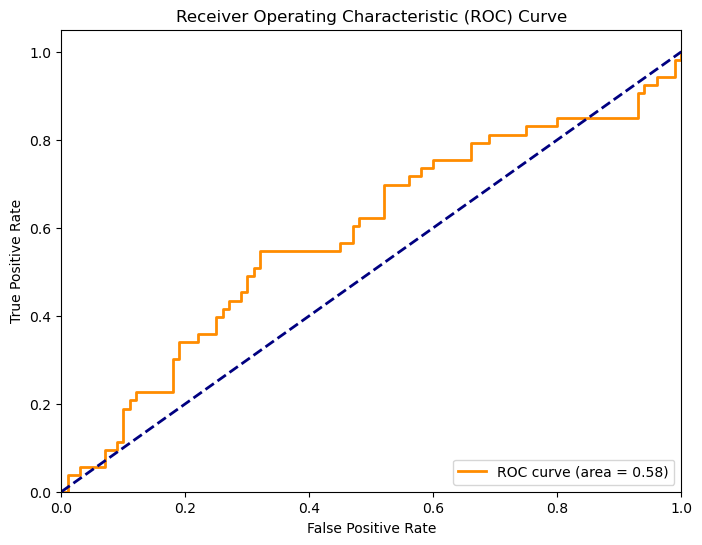

logistic_regression Test Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.34      0.96      0.50        54

    accuracy                           0.34       154
   macro avg       0.17      0.48      0.25       154
weighted avg       0.12      0.34      0.18       154



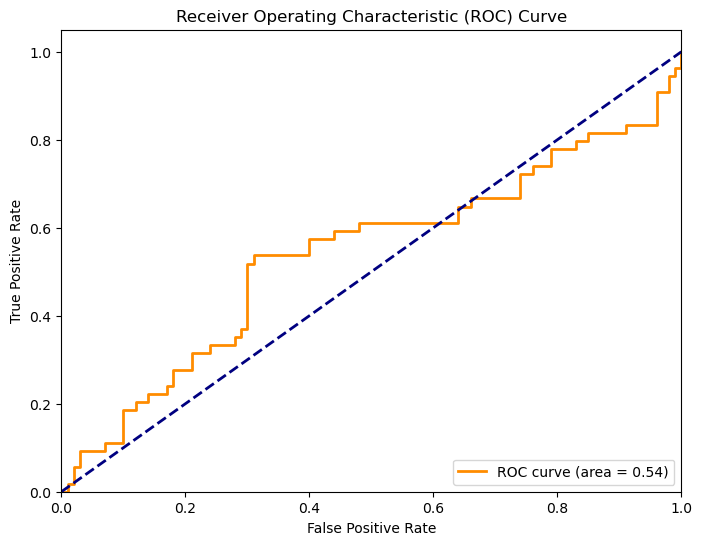

In [36]:
# Output
print("logistic_regression Validation Classification Report:")
print(classification_report(y_val, y_val_pred_logistic_regression))
get_roc_auc(y_val, best_logistic_regression.decision_function(X_val_transformed_scaled))

print("logistic_regression Test Classification Report:")
print(classification_report(y_test, y_test_pred_logistic_regression))
get_roc_auc(y_test, best_logistic_regression.decision_function(X_test_transformed_scaled))

### GaussianNB

In [37]:
# Hyper parameter tuning for gaussian_nb
def obj_gaussian_nb(trial):
    # Hyperparameter tuning suggestions for gaussian_nb fields
    var_smoothing = trial.suggest_float("var_smoothing", 1e-14, 1e-4, log=True)

    # Define the model
    model = GaussianNB(
        var_smoothing=var_smoothing
    )

    # Get f1_score
    f1_score = cross_val_score(
        model, 
        X_train_transformed_scaled,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro'
    ).mean()

    return f1_score

# Use Optuna to optimize the gaussian_nb model
study_gaussian_nb = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_gaussian_nb.optimize(obj_gaussian_nb, n_trials=100)

print(f"Best hyperparameters for gaussian_nb: {study_gaussian_nb.best_params}")
print(f"Best f1_score for gaussian_nb: {study_gaussian_nb.best_value}")

# Train gaussian_nb using best params 
best_gaussian_nb = GaussianNB(
    **study_gaussian_nb.best_params,
)
best_gaussian_nb.fit(X_train_transformed_scaled, y_train)

# Evaluate gaussian_nb on val and test data
y_val_pred_gaussian_nb = best_gaussian_nb.predict(X_val_transformed_scaled)
y_test_pred_gaussian_nb = best_gaussian_nb.predict(X_test_transformed_scaled)

Best hyperparameters for gaussian_nb: {'var_smoothing': 4.173640536702804e-09}
Best f1_score for gaussian_nb: 0.7279307353596451


gaussian_nb Validation Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.35      1.00      0.51        53

    accuracy                           0.35       153
   macro avg       0.17      0.50      0.26       153
weighted avg       0.12      0.35      0.18       153



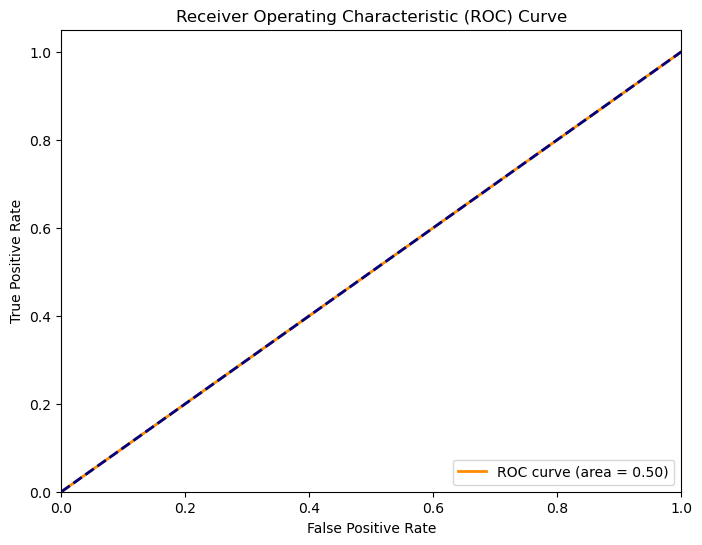

gaussian_nb Test Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.35      1.00      0.52        54

    accuracy                           0.35       154
   macro avg       0.18      0.50      0.26       154
weighted avg       0.12      0.35      0.18       154



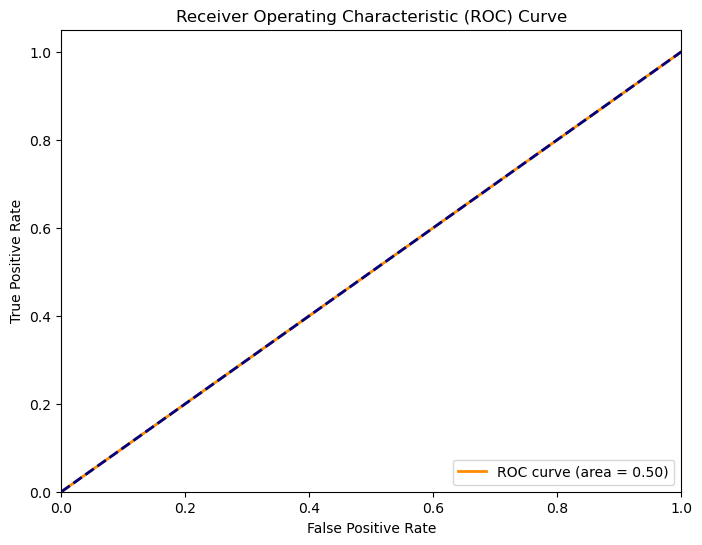

In [38]:
# Output
print("gaussian_nb Validation Classification Report:")
print(classification_report(y_val, y_val_pred_gaussian_nb))
get_roc_auc(y_val, y_val_pred_gaussian_nb)

print("gaussian_nb Test Classification Report:")
print(classification_report(y_test, y_test_pred_gaussian_nb))
get_roc_auc(y_test, y_test_pred_gaussian_nb)

### XGBoost

In [39]:
# Hyper parameter tuning for xg_boost
def obj_xg_boost(trial):
    # Hyperparameter tuning suggestions for xg_boost fields
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "use_label_encoder": False,
        "booster": trial.suggest_categorical("booster", ["gbtree", "dart"]),
        "lambda": trial.suggest_float("lambda", 1e-8, 10.0, log=True),   # L2 reg
        "alpha": trial.suggest_float("alpha", 1e-8, 10.0, log=True),     # L1 reg
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "eta": trial.suggest_float("eta", 1e-3, 0.3, log=True),          # learning rate
        "gamma": trial.suggest_float("gamma", 0, 10),
        "grow_policy": trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"]),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0)
    }

    # Define the model
    model = xgb.XGBClassifier(**params, random_state=42, n_jobs=-1)

    # Get f1_score
    f1_score = cross_val_score(
        model, 
        X_train_transformed_scaled,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro'
    ).mean()

    return f1_score

# Use Optuna to optimize the xg_boost model
study_xg_boost = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_xg_boost.optimize(obj_xg_boost, n_trials=100)

print(f"Best hyperparameters for xg_boost: {study_xg_boost.best_params}")
print(f"Best f1_score for xg_boost: {study_xg_boost.best_value}")

# Train xg_boost using best params 
best_xg_boost = xgb.XGBClassifier(
    **study_xg_boost.best_params,
    random_state=42,
    n_jobs=-1
)
best_xg_boost.fit(X_train_transformed_scaled, y_train)

# Evaluate xg_boost on val and test data
y_val_pred_xg_boost = best_xg_boost.predict(X_val_transformed_scaled)
y_test_pred_xg_boost = best_xg_boost.predict(X_test_transformed_scaled)

Best hyperparameters for xg_boost: {'booster': 'gbtree', 'lambda': 0.01513171892499672, 'alpha': 4.2017630574911366e-05, 'max_depth': 5, 'eta': 0.20323723714222913, 'gamma': 8.262443297891236, 'grow_policy': 'lossguide', 'subsample': 0.8516737517464659, 'colsample_bytree': 0.7987191312131151}
Best f1_score for xg_boost: 0.7472831158021427


xg_boost Validation Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       100
           1       0.69      0.72      0.70        53

    accuracy                           0.79       153
   macro avg       0.77      0.77      0.77       153
weighted avg       0.79      0.79      0.79       153



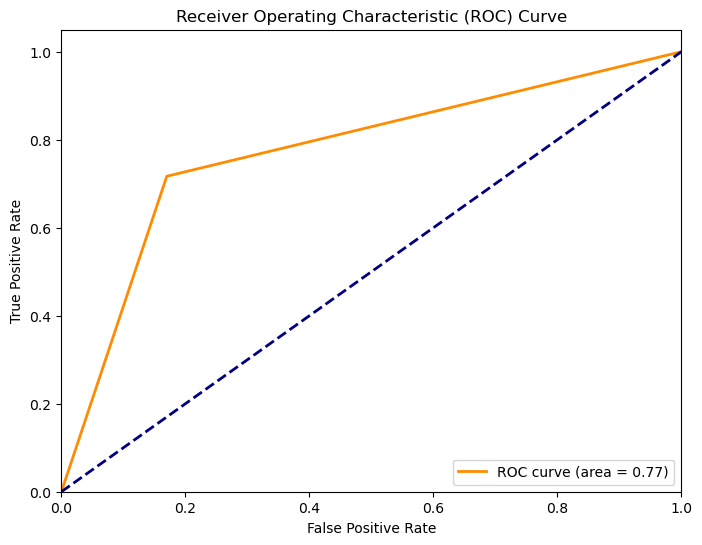

xg_boost Test Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.81      0.78       100
           1       0.60      0.52      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



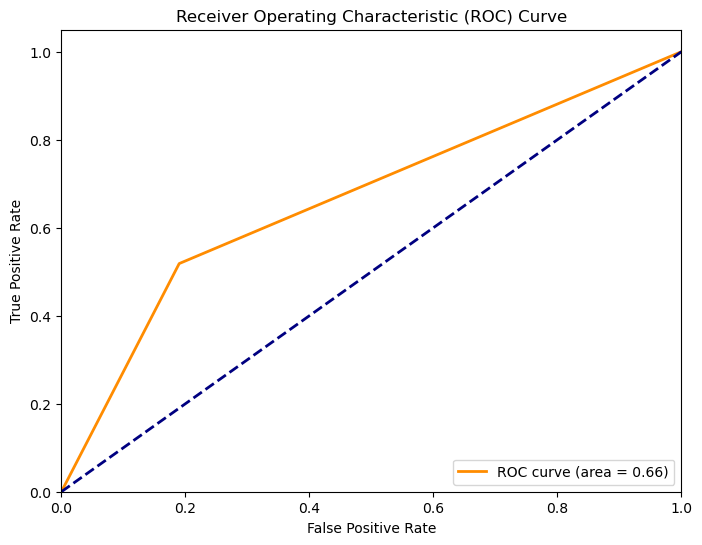

In [41]:
# Output
print("xg_boost Validation Classification Report:")
print(classification_report(y_val, y_val_pred_xg_boost))
get_roc_auc(y_val, y_val_pred_xg_boost)

print("xg_boost Test Classification Report:")
print(classification_report(y_test, y_test_pred_xg_boost))
get_roc_auc(y_test, y_test_pred_xg_boost)

## Non-Transformed Dataset

### Decision Tree

In [ ]:
# Hyper parameter tuning for decision_tree
def obj_decision_tree(trial):
    # Hyperparameter tuning suggestions for decision_tree fields
    max_depth = trial.suggest_int("max_depth", 2, 50)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])

    # define te model
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        random_state=42
    )

    # Get f1_score
    f1_score = cross_val_score(
        model, 
        X_train_scaled,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro'
    ).mean()

    return f1_score

# Use Optuna to optimize the decision_tree model
study_decision_tree = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_decision_tree.optimize(obj_decision_tree, n_trials=100)

print(f"Best hyperparameters for decision_tree: {study_decision_tree.best_params}")
print(f"Best f1_score for decision_tree: {study_decision_tree.best_value}")

# Train decision_tree using best params 
best_decision_tree = DecisionTreeClassifier(
    **study_decision_tree.best_params,
    random_state=42
)
best_decision_tree.fit(X_train_scaled, y_train)

# Evaluate decision_tree on val and test data
y_val_pred_decision_tree = best_decision_tree.predict(X_val_scaled)
y_test_pred_decision_tree = best_decision_tree.predict(X_test_scaled)

In [ ]:
# Output
print("decision_tree Validation Classification Report:")
print(classification_report(y_val, y_val_pred_decision_tree))
get_roc_auc(y_val, best_decision_tree.decision_function(X_val_scaled))

print("decision_tree Test Classification Report:")
print(classification_report(y_test, y_test_pred_decision_tree))
get_roc_auc(y_test, best_decision_tree.decision_function(X_test_scaled))

### RandomForest

In [ ]:
# Hyper parameter tuning for random_forest
def obj_random_forest(trial):
    # Hyperparameter tuning suggestions for random_forest fields
    n_estimators = trial.suggest_int("n_estimators", 100, 1000, step=100)
    max_depth = trial.suggest_int("max_depth", 3, 50)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    # Defin the model
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )

    # Get f1_score
    f1_score = cross_val_score(
        model, 
        X_train_scaled,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro'
    ).mean()

    return f1_score

# Use Optuna to optimize the random_forest model
study_random_forest = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_random_forest.optimize(obj_random_forest, n_trials=100)

print(f"Best hyperparameters for random_forest: {study_random_forest.best_params}")
print(f"Best f1_score for random_forest: {study_random_forest.best_value}")

# Train random_forest using best params 
best_random_forest = RandomForestClassifier(
    **study_random_forest.best_params,
    random_state=42
)
best_random_forest.fit(X_train_scaled, y_train)

# Evaluate random_forest on val and test data
y_val_pred_random_forest = best_random_forest.predict(X_val_scaled)
y_test_pred_random_forest = best_random_forest.predict(X_test_scaled)

In [ ]:
# Output
print("random_forest Validation Classification Report:")
print(classification_report(y_val, y_val_pred_random_forest))
get_roc_auc(y_val, best_random_forest.decision_function(X_val_scaled))

print("random_forest Test Classification Report:")
print(classification_report(y_test, y_test_pred_random_forest))
get_roc_auc(y_test, best_random_forest.decision_function(X_test_scaled))

### GradientBoosting

In [ ]:
# Hyper parameter tuning for gradient_boosting
def obj_gradient_boosting(trial):
    # Hyperparameter tuning suggestions for gradient_boosting fields
    n_estimators = trial.suggest_int("n_estimators", 100, 1000, step=100)
    learning_rate = trial.suggest_float("learning_rate", 1e-3, 0.2, log=True)
    max_depth = trial.suggest_int("max_depth", 2, 10)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    # Define the model
    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        subsample=subsample,
        max_features=max_features,
        random_state=42
    )

    # Get f1_score
    f1_score = cross_val_score(
        model, 
        X_train_scaled,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro'
    ).mean()

    return f1_score

# Use Optuna to optimize the gradient_boosting model
study_gradient_boosting = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_gradient_boosting.optimize(obj_gradient_boosting, n_trials=100)

print(f"Best hyperparameters for gradient_boosting: {study_gradient_boosting.best_params}")
print(f"Best f1_score for gradient_boosting: {study_gradient_boosting.best_value}")

# Train gradient_boosting using best params 
best_gradient_boosting = GradientBoostingClassifier(
    **study_gradient_boosting.best_params,
    random_state=42
)
best_gradient_boosting.fit(X_train_scaled, y_train)

# Evaluate gradient_boosting on val and test data
y_val_pred_gradient_boosting = best_gradient_boosting.predict(X_val_scaled)
y_test_pred_gradient_boosting = best_gradient_boosting.predict(X_test_scaled)

In [ ]:
# Output
print("gradient_boosting Validation Classification Report:")
print(classification_report(y_val, y_val_pred_gradient_boosting))
get_roc_auc(y_val, best_gradient_boosting.decision_function(X_val_scaled))

print("gradient_boosting Test Classification Report:")
print(classification_report(y_test, y_test_pred_gradient_boosting))
get_roc_auc(y_test, best_gradient_boosting.decision_function(X_test_scaled))

### XGBoost

In [ ]:
# Hyper parameter tuning for xg_boost
def obj_xg_boost(trial):
    # Hyperparameter tuning suggestions for xg_boost fields
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "use_label_encoder": False,
        "booster": trial.suggest_categorical("booster", ["gbtree", "dart"]),
        "lambda": trial.suggest_float("lambda", 1e-8, 10.0, log=True),   # L2 reg
        "alpha": trial.suggest_float("alpha", 1e-8, 10.0, log=True),     # L1 reg
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "eta": trial.suggest_float("eta", 1e-3, 0.3, log=True),          # learning rate
        "gamma": trial.suggest_float("gamma", 0, 10),
        "grow_policy": trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"]),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0)
    }

    # Define the model
    model = xgb.XGBClassifier(**params, random_state=42, n_jobs=-1)

    # Get f1_score
    f1_score = cross_val_score(
        model, 
        X_train_scaled,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro'
    ).mean()

    return f1_score

# Use Optuna to optimize the xg_boost model
study_xg_boost = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_xg_boost.optimize(obj_xg_boost, n_trials=100)

print(f"Best hyperparameters for xg_boost: {study_xg_boost.best_params}")
print(f"Best f1_score for xg_boost: {study_xg_boost.best_value}")

# Train xg_boost using best params 
best_xg_boost = xgb.XGBClassifier(
    **study_xg_boost.best_params,
    random_state=42,
    n_jobs=-1
)
best_xg_boost.fit(X_train_scaled, y_train)

# Evaluate xg_boost on val and test data
y_val_pred_xg_boost = best_xg_boost.predict(X_val_scaled)
y_test_pred_xg_boost = best_xg_boost.predict(X_test_scaled)

In [ ]:
# Output
print("xg_boost Validation Classification Report:")
print(classification_report(y_val, y_val_pred_xg_boost))
get_roc_auc(y_val, y_val_pred_xg_boost)

print("xg_boost Test Classification Report:")
print(classification_report(y_test, y_test_pred_xg_boost))
get_roc_auc(y_test, y_test_pred_xg_boost)